# 1. CARREGANDO OS DADOS

In [1]:
import pandas as pd

# carregando a base de dados
df = pd.read_csv('weapons_data.csv')

# exibe as primeiras 5 linhas do DataFrame
print("Primeiras 5 linhas:")
print(df.head())

print("\nInformações sobre o DataFrame:")
print(df.info())

Primeiras 5 linhas:
  Weapon Name  Ammo Count                                        Description  \
0       RGS50           3  The anti-materiel Launcher (AML) can lock on t...   
1      MGL140           5  Grenade launcher with mid-sized magazine, low ...   
2         M79           1      Deals area damage, requires skillful control.   
3     GATLING        1200  Insane fire rate and power, but reduces mobility.   
4         M60          68    Large magazines and solid mid-range fire power.   

                                Tags            Type  
0             HIGH DAMAGE, DESTROYER           Melee  
1        AREA OF EFFECT, HIGH DAMAGE           Rifle  
2         AREA OF EFFECT, PROJECTILE        Launcher  
3  HIGH FIRE POWER, INSANE FIRE RATE  Marksman Rifle  
4          MID RANGE, HIGH CLIP-SIZE      Projectile  

Informações sobre o DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 5 columns):
 #   Column       Non-Null Count  D

# 2. SEPARANDO AS TAGS EM LISTA

In [2]:
# ENGENHARIA DE FEATURES: PROCESSANDO A COLUNA TAGS

# OBJETIVO: TRANSFORMAR A COLUNA 'TAGS' DE TEXTO PARA UM FORMATO ANALISÁVEL PARA O MODELO

# 1. CRIAR UMA NOVA COLUNA "TAG_LIST"
# Para cada linha na coluna 'Tags', vamos:
#   a. Dividir a string pela vírgula (usando .split(',')) para criar uma lista.
#   b. Remover espaços em branco desnecessários de cada item da lista (usando .strip()).
# df['Tags_List'] = df['Tags'].apply(lambda x: [tag.strip() for tag in x.split(',')])

tags_list = []

for tags in df['Tags']:
    linha = []
    for tag in tags.split(','):
        linha.append(tag.strip())
    tags_list.append(linha)

df['Tags_List'] = tags_list

# 2. Verificar o resultado.
# Vamos exibir a coluna original 'Tags' ao lado da nova 'Tags_List' para ver a transformação.
print("Transformação da coluna 'Tags' em lista:")
print(df[['Weapon Name', 'Tags', 'Tags_List']].head())

Transformação da coluna 'Tags' em lista:
  Weapon Name                               Tags  \
0       RGS50             HIGH DAMAGE, DESTROYER   
1      MGL140        AREA OF EFFECT, HIGH DAMAGE   
2         M79         AREA OF EFFECT, PROJECTILE   
3     GATLING  HIGH FIRE POWER, INSANE FIRE RATE   
4         M60          MID RANGE, HIGH CLIP-SIZE   

                             Tags_List  
0             [HIGH DAMAGE, DESTROYER]  
1        [AREA OF EFFECT, HIGH DAMAGE]  
2         [AREA OF EFFECT, PROJECTILE]  
3  [HIGH FIRE POWER, INSANE FIRE RATE]  
4          [MID RANGE, HIGH CLIP-SIZE]  


# 3. CRIANDO COLUNAS PARA CADA TAG (ONE-HOT ENCODING)

In [3]:
# 3. Aplicar One-Hot Encoding a partir da nossa lista de tags.
# O método .get_dummies() cria novas colunas para cada tag única.
# A combinação .str.join('|') é um truque para que o get_dummies funcione corretamente em listas.
tags_encoded = df['Tags_List'].str.join('|').str.get_dummies()

# 4. Juntar as novas colunas de tags ao nosso dataframe original.
# O 'axis=1' significa que estamos juntando as colunas lado a lado.
df = pd.concat([df, tags_encoded], axis=1)

# 5. Verificar o dataframe final com as novas colunas.
print("\nDataFrame final com as novas colunas de atributos:")
# O .head() aqui mostrará as novas colunas no final, talvez seja preciso rolar para o lado.
print(df.head())


DataFrame final com as novas colunas de atributos:
  Weapon Name  Ammo Count                                        Description  \
0       RGS50           3  The anti-materiel Launcher (AML) can lock on t...   
1      MGL140           5  Grenade launcher with mid-sized magazine, low ...   
2         M79           1      Deals area damage, requires skillful control.   
3     GATLING        1200  Insane fire rate and power, but reduces mobility.   
4         M60          68    Large magazines and solid mid-range fire power.   

                                Tags            Type  \
0             HIGH DAMAGE, DESTROYER           Melee   
1        AREA OF EFFECT, HIGH DAMAGE           Rifle   
2         AREA OF EFFECT, PROJECTILE        Launcher   
3  HIGH FIRE POWER, INSANE FIRE RATE  Marksman Rifle   
4          MID RANGE, HIGH CLIP-SIZE      Projectile   

                             Tags_List  2x Scope  3 ROUND BURST  ACCURATE  \
0             [HIGH DAMAGE, DESTROYER]         0     

# Passo 4: Primeira Análise com os Novos Atributos

## 4.1. Calculando a Frequência de Cada Tag

In [4]:
# Quais são os atributos mais comuns em todas as armas do jogo?

# --- ANÁLISE EXPLORATÓRIA (EDA) ---

# Objetivo: Entender a distribuição dos atributos das armas.

# 1. Calcular a frequência de cada atributo.
# Somamos cada coluna de tag e ordenamos do maior para o menor.
frequencia_tags = tags_encoded.sum().sort_values(ascending=False)

print("\nFrequência de cada atributo no jogo:")
print(frequencia_tags)


Frequência de cada atributo no jogo:
HIGH DAMAGE                    13
LONG RANGE                     10
CLOSE RANGE                     8
High Damage                     5
MELEE                           5
Mid Range                       5
Long Range                      4
INSANE FIRE RATE                4
HIGH CLIP-SIZE                  4
SHIELD                          4
Rare                            3
HIGH FIRE RATE                  3
HIGH MOBILITY                   2
DAMAGE OVER TIME                2
RARE                            2
High Mobility                   2
SILENCED                        2
SHORT RANGE                     2
Secondary Weapon                2
PENETRATE THE ICE WALL          2
Akimbo                          2
Burst Fire                      2
Close Range                     2
HIGH FIRE POWER                 2
AREA OF EFFECT                  2
Healing                         2
CHARGEABLE                      1
Balanced                        1
HIGH ARMOR

## 4.2. Visualizando a Frequência

C:\Users\Marco\AppData\Local\Temp\ipykernel_17088\905891190.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=frequencia_tags.values, y=frequencia_tags.index, palette='viridis', orient='h')


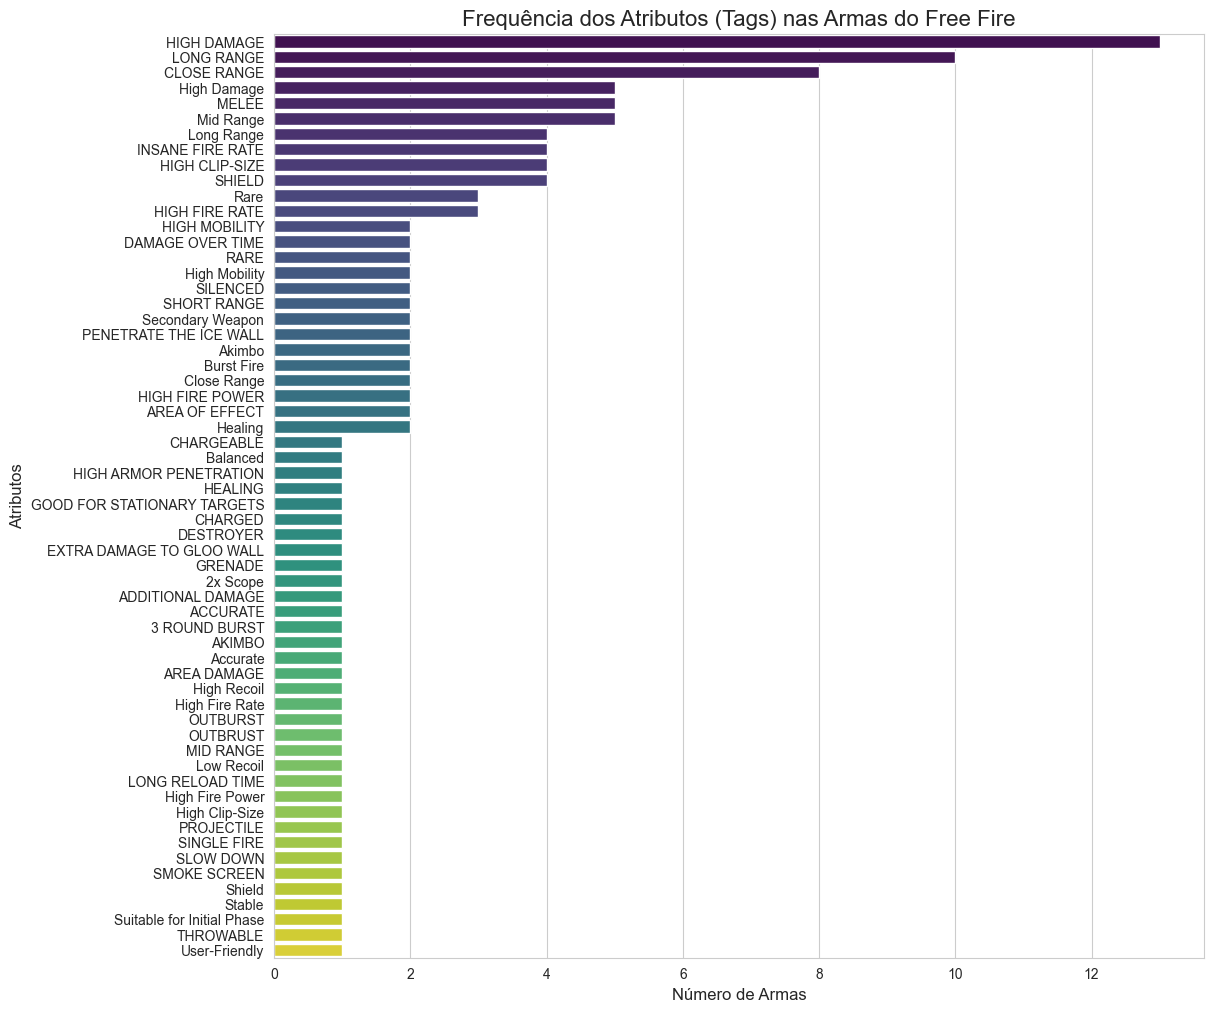

In [5]:
# importa as bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# define o estilo do gráfico
sns.set_style("whitegrid")

# 2. Criar o gráfico de barras para visualizar a frequência
plt.figure(figsize=(12, 12)) # define o tamanho do gráfico
ax = sns.barplot(x=frequencia_tags.values, y=frequencia_tags.index, palette='viridis', orient='h')

# adiciona título e rótulos
ax.set_title("Frequência dos Atributos (Tags) nas Armas do Free Fire", fontsize=16)
ax.set_xlabel("Número de Armas", fontsize=12)
ax.set_ylabel("Atributos", fontsize=12)

# mostra o gráfico
plt.show()

# 5 Análise de Atributos por Tipo de Arma

## 5.1. Agrupando os Dados

In [6]:
# --- ANÁLISE DE ATRIBUTOS POR TIPO ---

# Objetivo: Entender quais atributos são característicos de cada tipo de arma.

# 1. Agrupar o dataframe por 'Type' e somar os valores das colunas de tags.
# Isso nos dará uma tabela com a contagem de cada atributo para cada tipo de arma.
analise_por_tipo = df.groupby('Type')[tags_encoded.columns].sum()

# 2. Exibir a tabela resultante.
print("Contagem de atributos por tipo de arma:")
print(analise_por_tipo)

Contagem de atributos por tipo de arma:
                 2x Scope  3 ROUND BURST  ACCURATE  ADDITIONAL DAMAGE  AKIMBO  \
Type                                                                            
Bow                     0              0         0                  0       0   
Launcher                0              0         0                  0       0   
Machine gun             0              0         0                  0       0   
Marksman Rifle          0              0         0                  0       1   
Melee                   0              0         1                  0       0   
Pistol                  0              0         0                  0       0   
Projectile              0              0         0                  0       0   
Rifle                   1              0         0                  0       0   
Shotgun                 0              0         0                  0       0   
Sniper                  0              1         0                  0

## 5.2. Visualizando com um Mapa de Calor (Heatmap)

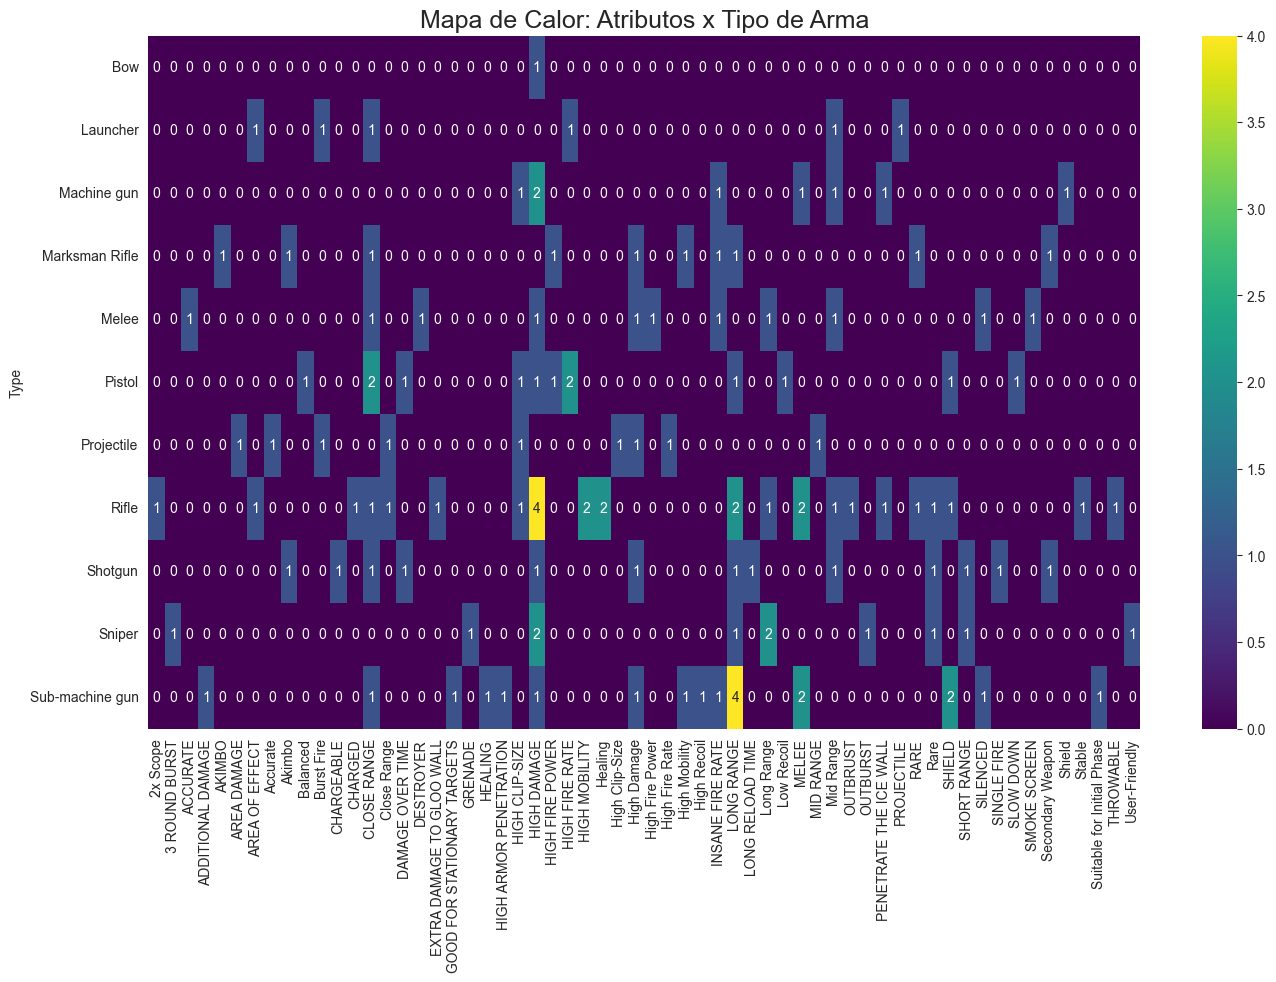

In [7]:
# 3. Criar um heatmap para visualizar a relação entre Tipo e Atributo.
# Um heatmap usa cores para representar valores, facilitando a identificação de padrões.

plt.figure(figsize=(16, 9)) # Aumentamos o tamanho para melhor legibilidade
ax = sns.heatmap(
    analise_por_tipo,
    annot=True, # 'annot=True' escreve os números dentro de cada célula
    cmap='viridis', # 'cmap' define a paleta de cores
    fmt='g' # 'fmt="g"' remove a notação científica e mostra números inteiros
)

# Adiciona título para clareza
ax.set_title('Mapa de Calor: Atributos x Tipo de Arma', fontsize=18)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0) # Garante que os rótulos do eixo Y fiquem na horizontal

# Mostra o gráfico
plt.show()